# Import Environment variables

In [6]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.ipynb

Found bucket: id=rw-migration-aou-rw-f7a4d148, bucketName=rw-migration-aou-rw-f7a4d148
-> Assigned migration variables (ID: rw-migration-aou-rw-f7a4d148)
Found bucket: id=temporary-workspace-bucket, bucketName=temporary-workspace-bucket-wb-perky-cabbage-8342
Found bucket: id=workspace-bucket, bucketName=workspace-bucket-wb-perky-cabbage-8342
✅ Successfully identified latest dataset: wb-silky-artichoke-2408.C2024Q3R9

Variables extracted:
GOOGLE_CLOUD_PROJECT: wb-perky-cabbage-8342
WORKSPACE_BUCKET: gs://workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_TEMP_BUCKET: gs://temporary-workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_CDR: wb-silky-artichoke-2408.C2024Q3R9
bucket_aou_tutorial: NOT FOUND
bucket_id_aou_tutorial: NOT FOUND
bucket_migrated: gs://rw-migration-aou-rw-f7a4d148
bucket_id_migrated: rw-migration-aou-rw-f7a4d148

✅ Saved to /home/jupyter/.bashrc
C2024Q3R9 BQ_DATASET
Multi-trait-GWAS-in-admixed-populations GIT_REPO
dataset_test2 BQ_DATASET
prep_C2024Q3R9 BQ_DATASET
rw-mig

In [7]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.ipynb

WORKSPACE_CDR = wb-silky-artichoke-2408.C2024Q3R9
WORKSPACE_BUCKET = gs://workspace-bucket-wb-perky-cabbage-8342
GOOGLE_PROJECT = wb-perky-cabbage-8342
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.R
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.sas


# Import library

In [8]:
%load_ext autoreload
%autoreload 2
    
import os
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data's import

## Data from `50_Breast_Cancer_WITHIN_5Y`

* Femmes n'ayant pas eu de cancer avant l'inclusion (BC and not BC included without time constraints) for all time)
* Origine génétique (RYE)
* Biopsie

In [9]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_TEMP_BUCKET')
name_of_file_in_bucket = "df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry_biopsy.tsv"

# save dataframe in a csv file in the same workspace as the notebook
df_bc = pd.read_csv(my_bucket +'/'+ name_of_file_in_bucket, sep=',', low_memory=False)
df_bc

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,...,date_3_of_biopsy_19100_19103,has_biopsy_19100_19103,date_1_of_biopsy_19120_19125_19126,date_2_of_biopsy_19120_19125_19126,date_3_of_biopsy_19120_19125_19126,has_biopsy_19120_19125_19126,biopsy_result,first_any_biopsy_date,days_inclusion_to_biopsy,days_biopsy_to_cancer
0,7604109,Female,1953-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-03-29,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
1,2382559,Female,1988-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-04-04,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
2,2032331,Female,1954-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-09-17,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
3,3382692,Female,1957-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2018-07-17,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
4,2537673,Female,1965-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-03-04,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223201,8122695,Female,2002-06-15,Not Hispanic or Latino,White,2023-06-21,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
223202,3902303,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-12,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
223203,9743793,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-27,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN
223204,4702863,Female,2003-06-15,Not Hispanic or Latino,White,2023-02-24,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN


# Family History data processing

## Importing family_history data (statement)

In [10]:
# This query represents dataset "Personal and family health history (with datetime)" for domain "survey" and was generated for All of Us Controlled Tier Dataset v8
dataset_80480060_survey_sql = """
    SELECT
        answer.person_id,
        answer.survey_datetime,
        answer.survey,
        answer.question,
        answer.answer,
        answer.survey_version_name  
    FROM
        `""" + os.environ["WORKSPACE_CDR"] + """.ds_survey` answer   
    WHERE
        (
            question_concept_id IN (836772)
        )"""

dataset_80480060_survey_df = pd.read_gbq(
    dataset_80480060_survey_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")

dataset_80480060_survey_df.head(5)

/tmp/ipykernel_4776/2645985512.py:17: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  dataset_80480060_survey_df = pd.read_gbq(


Downloading:   0%|          |

,person_id,survey_datetime,survey,question,answer,survey_version_name
0,3506594,2023-03-01 01:09:16+00:00,Personal and Family Health History,"Including yourself, who in your family has had...","Including yourself, who in your family has had...",None
1,1083314,2023-04-21 16:22:14+00:00,Personal and Family Health History,"Including yourself, who in your family has had...","Including yourself, who in your family has had...",None
2,1657008,2018-10-12 22:34:14+00:00,Personal and Family Health History,"Including yourself, who in your family has had...","Including yourself, who in your family has had...",None
3,1382181,2020-04-26 16:20:36+00:00,Personal and Family Health History,"Including yourself, who in your family has had...","Including yourself, who in your family has had...",None
4,1565942,2019-12-29 23:59:13+00:00,Personal and Family Health History,"Including yourself, who in your family has had...","Including yourself, who in your family has had...",None


In [11]:
dataset_80480060_survey_df['answer'].value_counts()

answer
PMI: Skip                                                                      84502
Including yourself, who in your family has had breast cancer? - Grandparent    31388
Including yourself, who in your family has had breast cancer? - Mother         27214
Including yourself, who in your family has had breast cancer? - Sibling        13804
Including yourself, who in your family has had breast cancer? - Self           10627
Including yourself, who in your family has had breast cancer? - Daughter        1250
Including yourself, who in your family has had breast cancer? - Father           824
Including yourself, who in your family has had breast cancer? - Son               57
Name: count, dtype: int64

# Features engineering

## Création d'une colonne par membres de la famille

In [12]:
list_answer = list(dataset_80480060_survey_df['answer'].unique())
list_answer

['Including yourself, who in your family has had breast cancer? - Daughter',
 'Including yourself, who in your family has had breast cancer? - Father',
 'Including yourself, who in your family has had breast cancer? - Grandparent',
 'Including yourself, who in your family has had breast cancer? - Mother',
 'Including yourself, who in your family has had breast cancer? - Self',
 'Including yourself, who in your family has had breast cancer? - Sibling',
 'PMI: Skip',
 'Including yourself, who in your family has had breast cancer? - Son']

In [13]:
# 1. Nettoyer les noms des colonnes pour ne garder que le membre de la famille
# On retire le préfixe répétitif pour avoir des colonnes lisibles
dataset_80480060_survey_df['clean_answer'] = dataset_80480060_survey_df['answer'].str.split(' - ').str[-1]

In [14]:
family_list = ['Daughter','Mother','Sibling']

df_survey_family = dataset_80480060_survey_df[dataset_80480060_survey_df['clean_answer'].isin(family_list)]

In [15]:
df_survey_clean = df_survey_family.copy()

# 2. Création d'une colonne de présence (1) pour le pivot
df_survey_clean['presence'] = 1

# 3. Pivotage : on transforme les valeurs de 'answer' en colonnes
# On utilise 'max' pour que si la personne a répondu 2 fois la même chose, on garde juste 1
df_pivot = df_survey_clean.pivot_table(
    index='person_id', 
    columns='clean_answer', 
    values='presence', 
    aggfunc='max'
).fillna(0).astype(int)

## Traitement des dates

### Ajout d'une colonne `first` et `last`

In [16]:
dataset_80480060_survey_df['survey_day'] = pd.to_datetime(dataset_80480060_survey_df['survey_datetime'], errors="coerce").dt.tz_localize(None).dt.normalize()

In [17]:
# 4. Récupération des dates (Première et Dernière réponse)
# C'est important pour savoir à quel moment l'info a été collectée
df_dates = dataset_80480060_survey_df.groupby('person_id')['survey_day'].agg(
    first_survey_date='min',
    last_survey_date='max'
)

### Ajout d'une variable `days_last_survey_to_first_survey` pour identifier le délai entre la 1ère et la dernière réponses au questionnaire

In [18]:
df_dates['days_last_survey_to_first_survey'] = (df_dates['last_survey_date'] - df_dates['first_survey_date']).dt.days

## Rassemblement des données contenant les antécédent familiaux 

In [19]:
df_family_history = df_dates.merge(df_pivot, on='person_id', how='right')

# Fusion avec le main set

In [20]:
df = df_bc.merge(df_family_history, on='person_id', how='left', indicator=True)
df

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,...,first_any_biopsy_date,days_inclusion_to_biopsy,days_biopsy_to_cancer,first_survey_date,last_survey_date,days_last_survey_to_first_survey,Daughter,Mother,Sibling,_merge
0,7604109,Female,1953-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-03-29,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
1,2382559,Female,1988-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-04-04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
2,2032331,Female,1954-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-09-17,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
3,3382692,Female,1957-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2018-07-17,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
4,2537673,Female,1965-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-03-04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223201,8122695,Female,2002-06-15,Not Hispanic or Latino,White,2023-06-21,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
223202,3902303,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-12,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
223203,9743793,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-27,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only
223204,4702863,Female,2003-06-15,Not Hispanic or Latino,White,2023-02-24,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,left_only


In [21]:
df['_merge'].value_counts()

_merge
left_only     207305
both           15901
right_only         0
Name: count, dtype: int64

In [22]:
df = df.drop(columns='_merge')

# Feature engineering - Etape 2

## Ajout d'une variable `days_inclusion_to_first_survey` pour identifier le délai entre la 1ère réponse au questionnaire et la date d'inclusion

In [23]:
df['inclusion_date'] = pd.to_datetime(df['inclusion_date'], errors="coerce").dt.tz_localize(None).dt.normalize()

In [24]:
df['days_inclusion_to_first_survey'] = (df['first_survey_date'] - df['inclusion_date']).dt.days

## Ajout d'une variable `days_inclusion_to_last_survey` pour identifier le délai entre la dernière réponse au questionnaire et la date d'inclusion

In [25]:
df['days_inclusion_to_last_survey'] = (df['last_survey_date'] - df['inclusion_date']).dt.days

## Ajout d'une variable `days_has_bc_to_first_survey` pour obtenir le délai entre la date de cancer du sein et la date de questionnaire

In [26]:
df['first_breast_cancer_date'] = pd.to_datetime(df['first_breast_cancer_date'], errors="coerce").dt.tz_localize(None).dt.normalize().dropna()

In [27]:
df['days_has_bc_to_first_survey'] = (df['first_breast_cancer_date'] - df['first_survey_date']).dt.days.dropna()

### Nombre d'individus ayant déjà un cancer du sein en répondant au questionnaire

In [28]:
len(df[df['days_has_bc_to_first_survey'] < 0]) # Déjà malades à l'inclusion

41

### Nombre d'individus ayant eu un cancer après le questionnaire, soit pendant l'étude

In [29]:
len(df[df['days_has_bc_to_first_survey'] > 0]) # Devenus malades pendant l'étude

152

## Ajout d'une variable `days_has_bc_to_last_survey` pour obtenir le délai entre la date de cancer du sein et la date de questionnaire

In [30]:
df['days_has_bc_to_last_survey'] = (df['first_breast_cancer_date'] - df['last_survey_date']).dt.days.dropna()

### Nombre d'individus ayant déjà un cancer du sein en répondant au questionnaire

In [31]:
len(df[df['days_has_bc_to_last_survey'] < 0]) # Déjà malades à l'inclusion

43

### Nombre d'individus ayant eu un cancer après le questionnaire, soit pendant l'étude

In [32]:
len(df[df['days_has_bc_to_last_survey'] > 0]) # Devenus malades pendant l'étude

150

# EDA

In [33]:
df_family_history = df[['person_id','first_survey_date','last_survey_date',
                        'days_last_survey_to_first_survey',
                        'Daughter','Mother','Sibling',
                        'days_inclusion_to_first_survey','days_inclusion_to_last_survey',
                        'days_has_bc_to_first_survey','days_has_bc_to_last_survey'
                       ]].dropna()

## EDA - Univarié

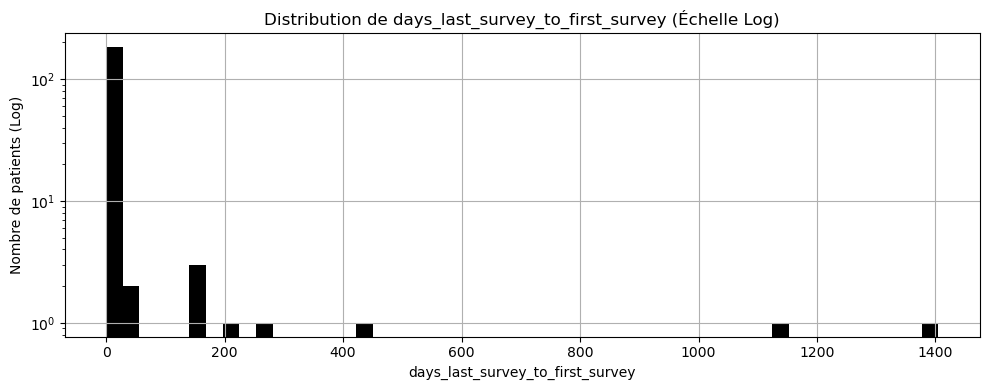

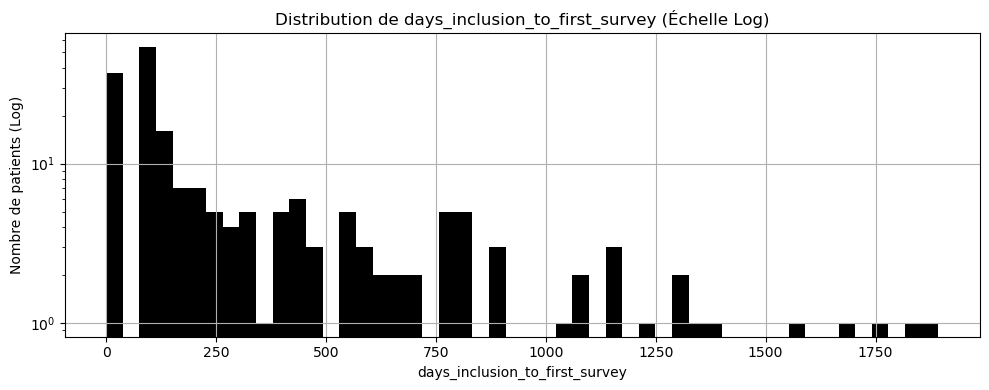

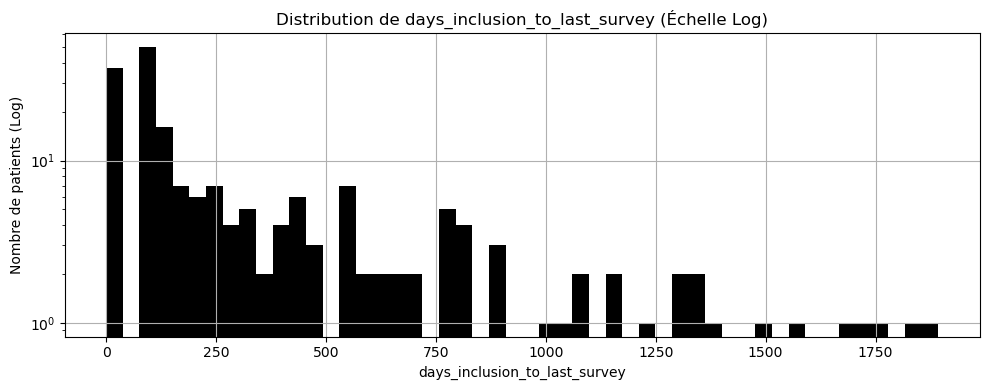

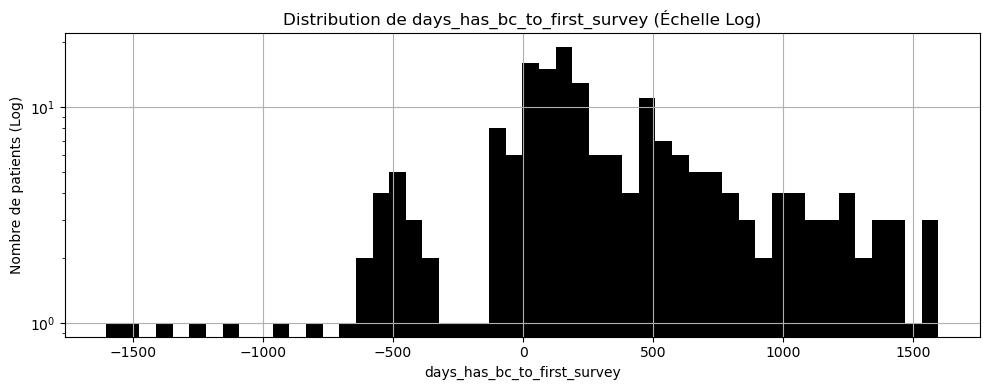

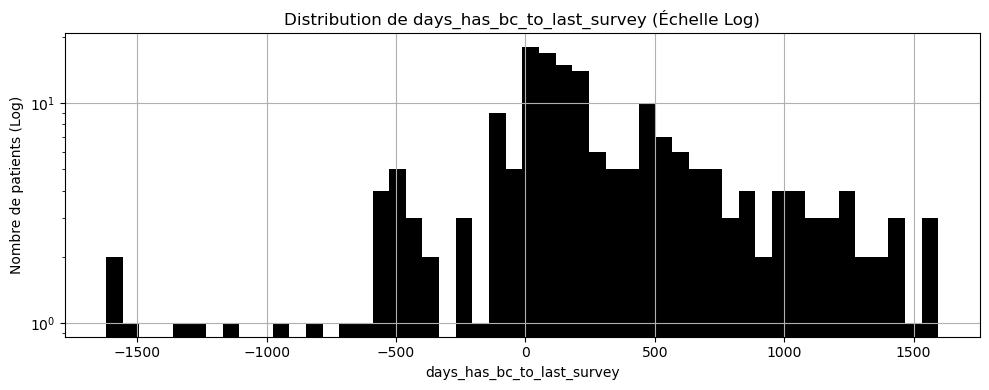

In [34]:
# Création de l'histogramme avec échelle log sur l'axe Y
cols = ['days_last_survey_to_first_survey','days_inclusion_to_first_survey',
        'days_inclusion_to_last_survey',
        'days_has_bc_to_first_survey','days_has_bc_to_last_survey']

for col in cols:
    plt.figure(figsize=(10, 4))
    df_family_history[col].hist(bins=50, log=True, color='black')
    
    plt.title(f'Distribution de {col} (Échelle Log)')
    plt.xlabel(col)
    plt.ylabel('Nombre de patients (Log)')
    plt.tight_layout()
    plt.show()

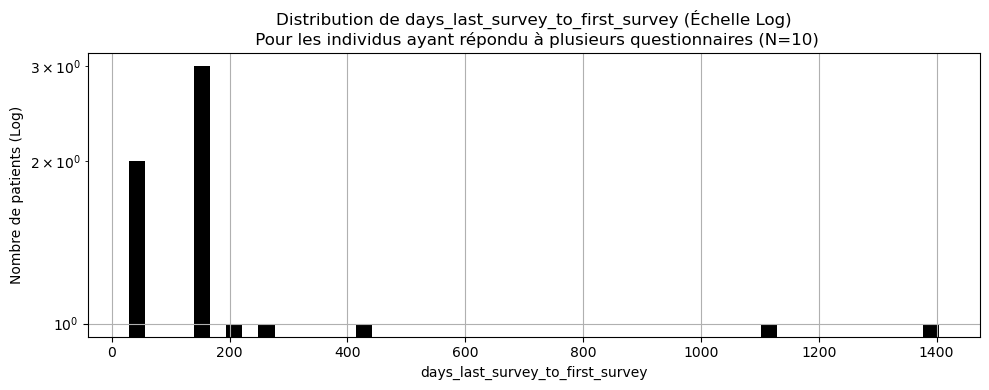

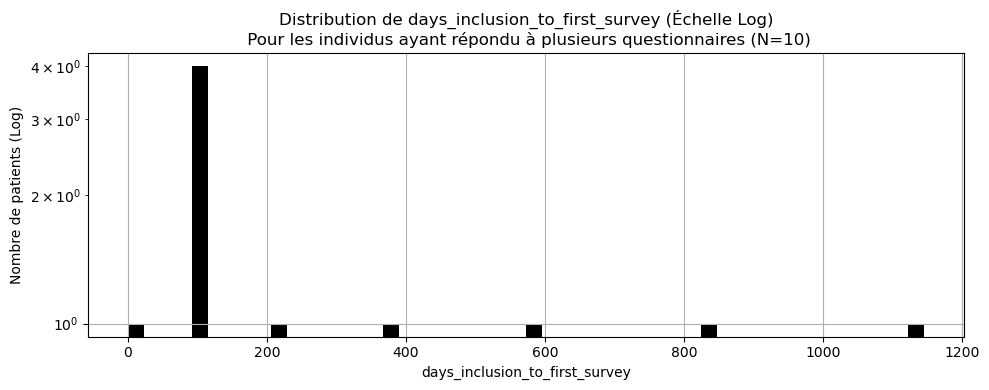

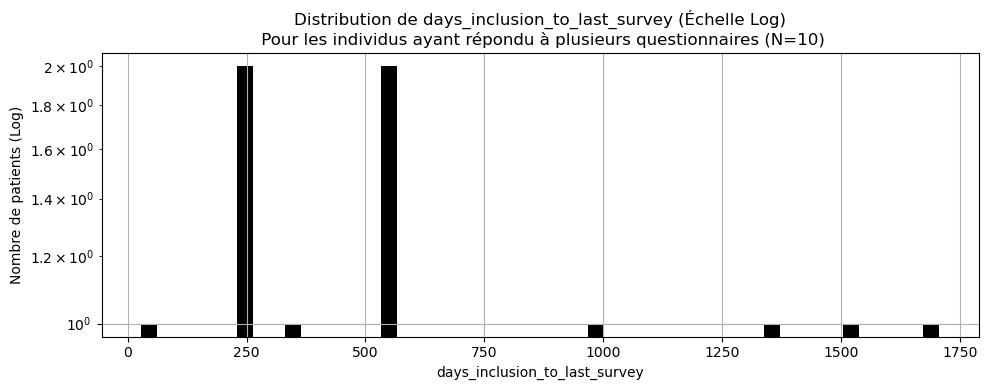

In [35]:
# Création de l'histogramme avec échelle log sur l'axe Y
cols = ['days_last_survey_to_first_survey','days_inclusion_to_first_survey','days_inclusion_to_last_survey']

df_multi_survey_answer = df_family_history.loc[df['days_inclusion_to_first_survey'] != df['days_inclusion_to_last_survey']]

N=len(df_multi_survey_answer)

for col in cols:
    plt.figure(figsize=(10, 4))
    df_multi_survey_answer[col].hist(bins=50, log=True, color='black')
    
    plt.title(f'Distribution de {col} (Échelle Log)\n Pour les individus ayant répondu à plusieurs questionnaires (N={N})')
    plt.xlabel(col)
    plt.ylabel('Nombre de patients (Log)')
    plt.tight_layout()
    plt.show()

## Combinations analysis of family history

In [36]:
df_combinations_family_history = df[['person_id','has_bc','Daughter','Mother','Sibling']].dropna()

In [37]:
!pip install upsetplot

### The intersection of family history

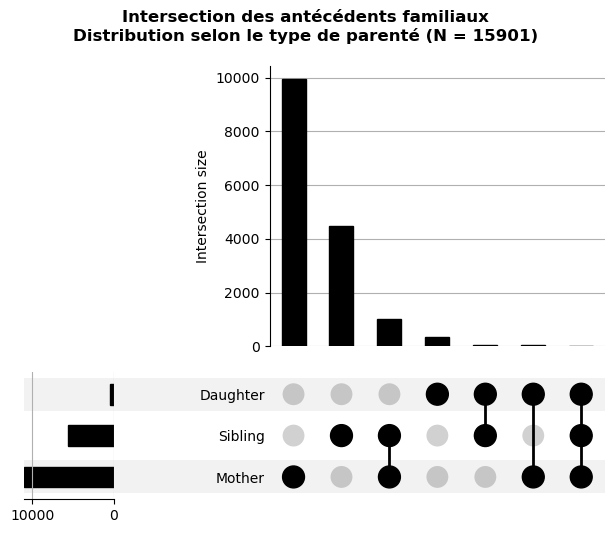

In [38]:
import warnings
from upsetplot import UpSet

# 1️⃣ Masquer les avertissements pour nettoyer la console
warnings.simplefilter(action="ignore", category=FutureWarning)

# 2️⃣ Extraction dynamique des colonnes d'antécédents
cols = df_combinations_family_history[['Daughter','Mother','Sibling']].columns.tolist()

# Correction de la variable N pour correspondre à ton DataFrame
N = len(df_combinations_family_history)

# 3️⃣ Pré-agrégation avec Pandas (indispensable pour contourner le bug NumPy 2.x)
df_bool = df_combinations_family_history[cols].astype(bool)
data_counts = df_bool.groupby(cols).size()

# 4️⃣ Configuration de la figure
fig = plt.figure(figsize=(14, 10))

# 5️⃣ Création de l'UpSetPlot
# /!\ On retire show_counts et show_percentages pour éviter le crash de type TypeError
up = UpSet(data_counts, sort_by="cardinality", element_size=45)

up.plot(fig=fig)

# 6️⃣ Titre principal (ajusté avec 'y' pour éviter les chevauchements)
plt.suptitle(
    f"Intersection des antécédents familiaux\n"
    f"Distribution selon le type de parenté (N = {N})\n",
    fontsize=12,
    fontweight="bold",
)

plt.show()

### Family history in individuals who have had breast cancer

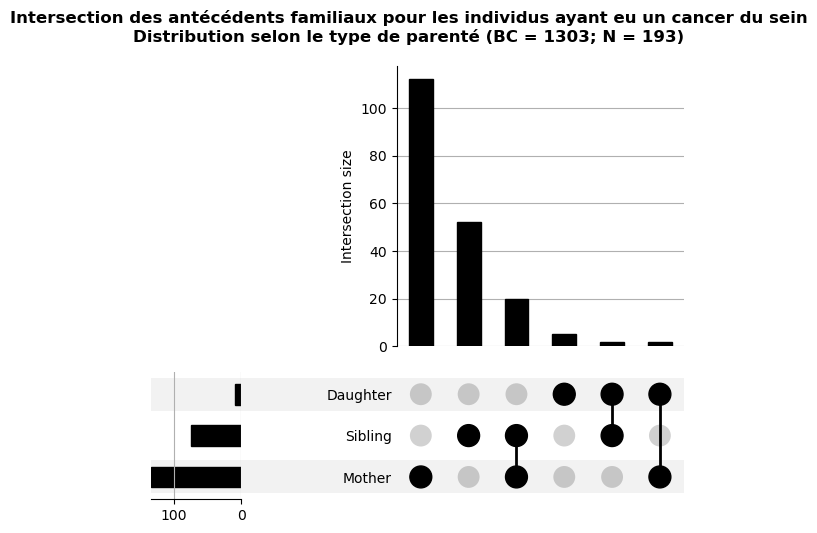

In [39]:
# 1️⃣ On masque les alertes pour la propreté du notebook
warnings.simplefilter(action="ignore", category=FutureWarning)

# 2️⃣ Ton filtrage : on ne garde que les individus avec un cancer du sein
df_filtered = df[df["has_bc"] == 1]

# 3️⃣ Pré-agrégation Pandas (indispensable pour contourner le crash de NumPy)
df_bool = df_filtered[cols].dropna().astype(bool)
data_counts = df_bool.groupby(cols).size()

# Le N correspond maintenant uniquement aux personnes filtrées
BC = len(df_filtered)
N = len(df_bool)

# 4️⃣ Configuration de la figure
fig = plt.figure(figsize=(14, 10))

# 5️⃣ Création de l'UpSetPlot
# /!\ On supprime show_counts et show_percentages pour éviter le TypeError
up = UpSet(data_counts, sort_by="cardinality", element_size=45)

up.plot(fig=fig)

# 6️⃣ Titre
plt.suptitle(
    f"Intersection des antécédents familiaux pour les individus ayant eu un cancer du sein\n"
    f"Distribution selon le type de parenté (BC = {BC}; N = {N})",
    fontsize=12,
    fontweight="bold",
)

plt.show()

### Cancer prevalence by combinations of family history

In [40]:
summary = (
    df
    .groupby(cols)["has_bc"]
    .agg(
        n_individuals="count",
        n_bc="sum",
        prevalence_bc="mean"
    )
    .reset_index()
)

summary["prevalence_bc"] = summary["prevalence_bc"] * 100

summary

,Daughter,Mother,Sibling,n_individuals,n_bc,prevalence_bc
0,0.0,0.0,1.0,4492,52,1.157614
1,0.0,1.0,0.0,9927,112,1.128236
2,0.0,1.0,1.0,1010,20,1.980198
3,1.0,0.0,0.0,347,5,1.440922
4,1.0,0.0,1.0,56,2,3.571429
5,1.0,1.0,0.0,54,2,3.703704
6,1.0,1.0,1.0,15,0,0.000000


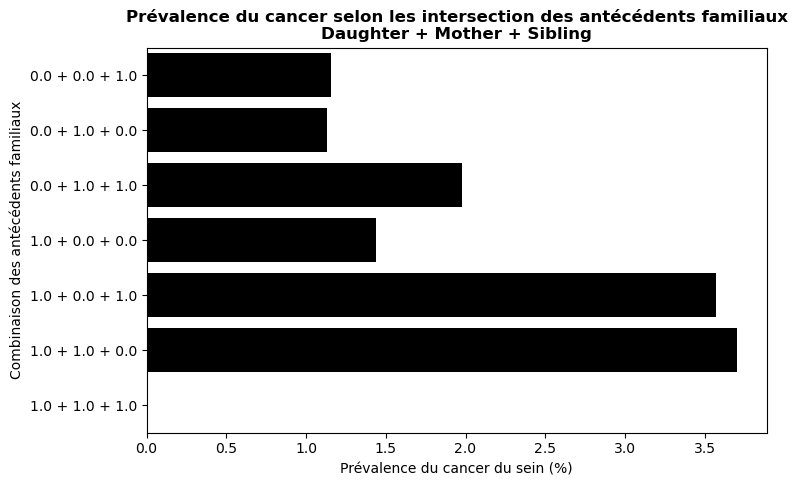

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=summary,
    x="prevalence_bc",
    y=summary[cols].astype(str).agg(" + ".join, axis=1),
    color="#000"
)

plt.xlabel("Prévalence du cancer du sein (%)")
plt.ylabel("Combinaison des antécédents familiaux")
plt.title("Prévalence du cancer selon les intersection des antécédents familiaux\nDaughter + Mother + Sibling", weight="bold")

plt.show()

# Data's export

In [43]:
destination_filename = 'Datas/df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry_biopsy_FamilyHistory.tsv'
df.to_csv(destination_filename, index=False)

# Récupère le nom du bucket Google Cloud depuis la variable d’environnement
my_bucket = os.getenv('WORKSPACE_TEMP_BUCKET')

# Copie le fichier TSV local dans le dossier "Data" du bucket
args = ["gsutil", "cp", f"./{destination_filename}", f"{my_bucket}"]
output = subprocess.run(args, capture_output=True)

# Affiche les éventuelles erreurs retournées par gsutil
output.stderr

b'Copying file://./Datas/df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry_biopsy_FamilyHistory.tsv [Content-Type=text/tab-separated-values]...\n/ [0 files][    0.0 B/ 47.6 MiB]                                                \r/ [1 files][ 47.6 MiB/ 47.6 MiB]                                                \r-\r\nOperation completed over 1 objects/47.6 MiB.                                     \n'